In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from utils import load_images_from_path

images, names = load_images_from_path("../data/undistorted")
pairs = [
    ["set_1_1.jpg", "set_1_2.jpg"],
    ["set_2_1.jpg", "set_2_2.jpg"],
    ["set_3_1.jpg", "set_3_2.jpg"],
]
image_pairs = []
for name1, name2 in pairs:
    img1 = images[names.index(name1)]
    img2 = images[names.index(name2)]
    image_pairs.append((img1, img2))

In [3]:
from projective_transformation import ORBDetector, project_on_plane
from utils import plot_img, save_image

orb = ORBDetector()

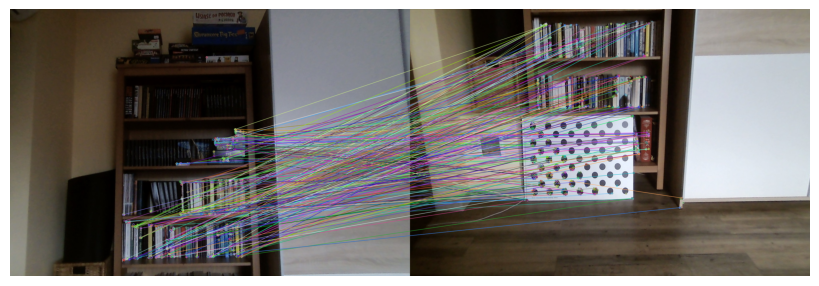

In [4]:
import cv2
import numpy as np

img1, img2 = image_pairs[1]
keypoints_1, keypoints_2, matches = orb.find_matches(img1, img2)

img3 = cv2.drawMatches(img1, keypoints_1, img2, keypoints_2, matches, None)

plot_img(img3)

In [5]:
Hs = orb.find_homographies(image_pairs)

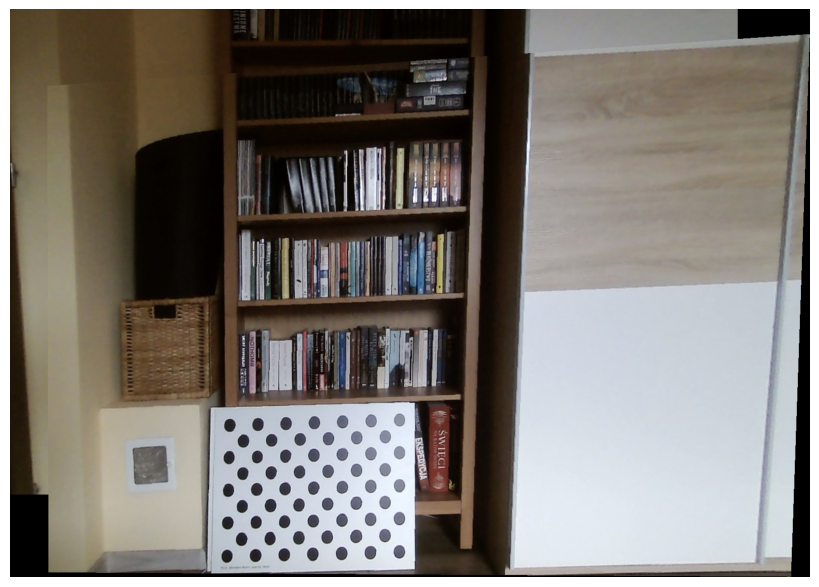

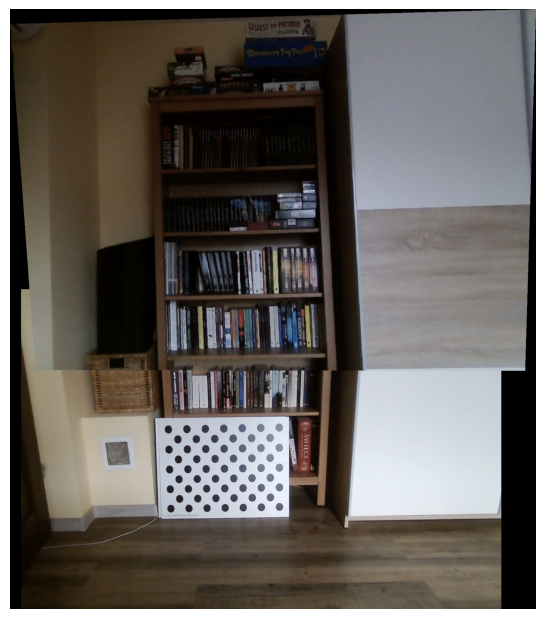

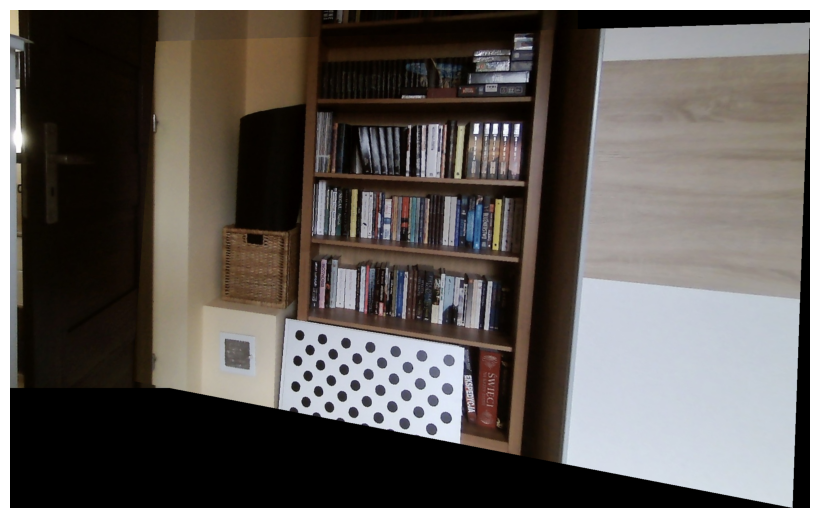

In [6]:
i = 1
for (img1, img2), H in list(zip(image_pairs, Hs)):
    warped_img1 = project_on_plane(img1, H, img2)
    plot_img(warped_img1)
    save_image(warped_img1, f"../data/orb/simple_projection/pair_{i}.png")
    i += 1

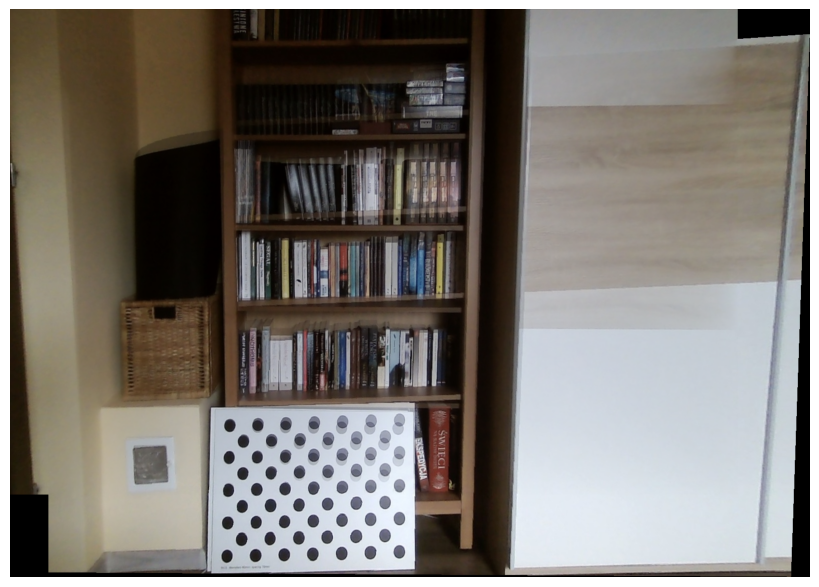

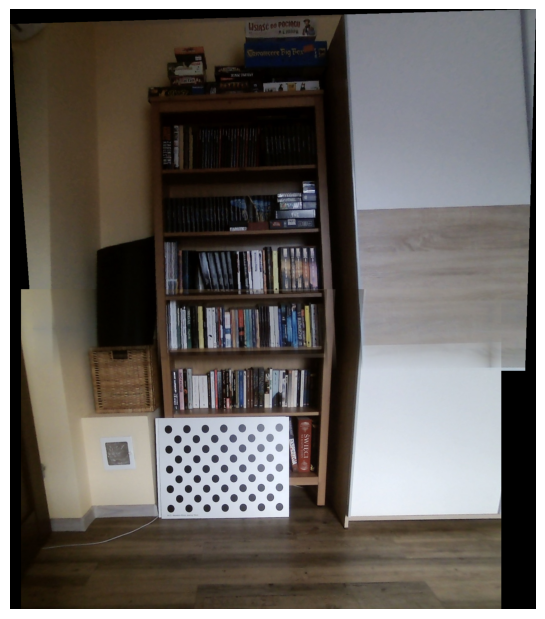

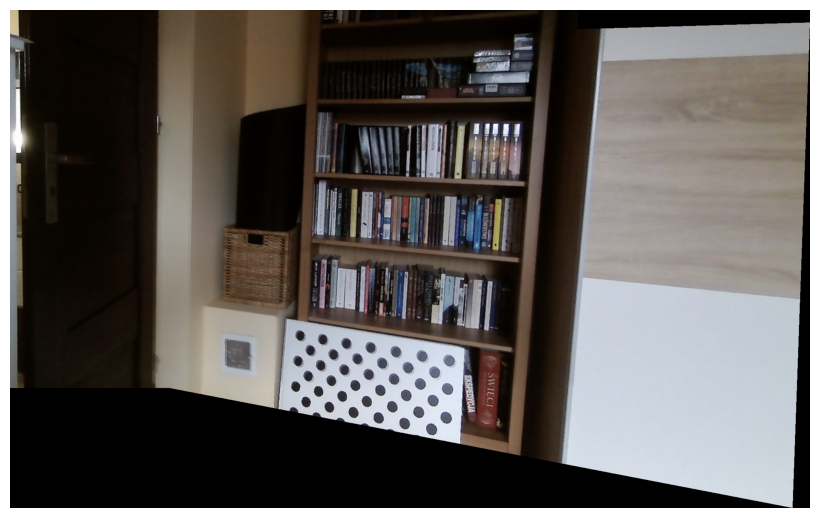

In [7]:
from projective_transformation import linear_stitching

i = 1
for (img1, img2), H in zip(image_pairs, Hs):
    stitched_img = linear_stitching(img1, H, img2)
    plot_img(stitched_img)
    save_image(stitched_img, f"../data/orb/linear_stitching/pair_{i}.png")
    save_image(stitched_img, f"../data/results/task_6_stitched_pair_{i}.jpg")
    i += 1